# `CRO` fitting with observation

This tutorial illustrates how to use the `pyCRO` to estimate RO parameters from the observations

This notebook was contributed by [Sen Zhao](https://senzhao.netlify.app/).


## Load library

In [1]:
%config IPCompleter.greedy = True
%matplotlib inline
%config InlineBackend.figure_format='retina'

%load_ext autoreload
%autoreload 2

import os
import sys
    
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt

## comment this if you install pyCRO already
sys.path.append(os.path.abspath("../../../"))

import pyCRO

In [2]:
pyCRO.RO_fitting?

Signature:
pyCRO.RO_fitting(
    T,
    h,
    par_option_T,
    par_option_h,
    par_option_noise,
    method_fitting=None,
    dt=None,
    verbose=True,
)
Docstring:
Fit the Recharge Oscillator (RO) model parameters to T and h time series.

This function performs parameter fitting for the RO system, using the specified
prescribed parameter options and noise characteristics. Fitting can be done 
via linear regression (LR) or maximum likelihood estimation (MLE), with optional
handling for multiplicative or additive noise. It can automatically select a
default fitting method based on parameter options.

Parameters
----------
T : ndarray, shape (N,) or (N, 1)
    Time series of SST anomalies (1D array).
h : ndarray, shape (N,) or (N, 1)
    Time series of thermocline anomalies (1D array).
par_option_T : dict
    Prescribed options for SST equation parameters.
        
        Keys (R, F1, b_T, c_T, d_T):
        
        Each entry Xi ∈ {0, 1, 3, 5}:
            0 : parameter not inclu

## RO Parameter Fitting Usage

**`par_fitted = pyCRO.RO_fitting(T, h, par_option_T, par_option_h, par_option_noise)`**

### Input T and h Time Series

- T and h are input timeseries used for the fitting.
- T and h must be 1D time series arrays with a uniform time step. 

### Specifiying RO Type

These options define the RO model type used for fitting.
- **par_option_T** specifies the linear and nonlinear terms in dT/dt
- **par_option_h** specifies the linear and nonlinear terms in dh/dt
- **par_option_noise** specifies the noise type

The following example shows how to set the RO type as linear-white-additive RO for the fitting.
```python
par_option_T = {"R": 1, "F1": 1, "b_T": 0, "c_T": 0, "d_T": 0}
par_option_h = {"F2": 1, "epsilon": 1, "b_h": 0}
```
- For keys in `par_option_T` and `par_option_h`, allowed values are:
  - `0` — Do not estimate
  - `1` — Estimate only the annual mean
  - `3` — Estimate annual mean + annual seasonality
  - `5` — Estimate annual mean + annual + semi-annual seasonality
    
```python
par_option_noise = {"T": "white", "h": "white", "T_type": "multiplicative"}
```
- Valid options for $T$ and $h$ are: 
    - `"white"`: white noise forcing
    - `"red"`: red noise forcing
- Both $T$ and $h$ **must use the same noise type**; otherwise, an error is raised.
- Valid options for `T-type` (noise structure for $T$) are:  
    - `"additive"`: T noise forcing is additive
    - `"multiplicative"`: T noise forcing is multiplicative
    - `"multiplicative-H"`: T noise forcing is Heaviside based-multiplicative noise


## Fitting RO to the observation/reanalysis

### Load observed ENSO timeseries from ORAS5

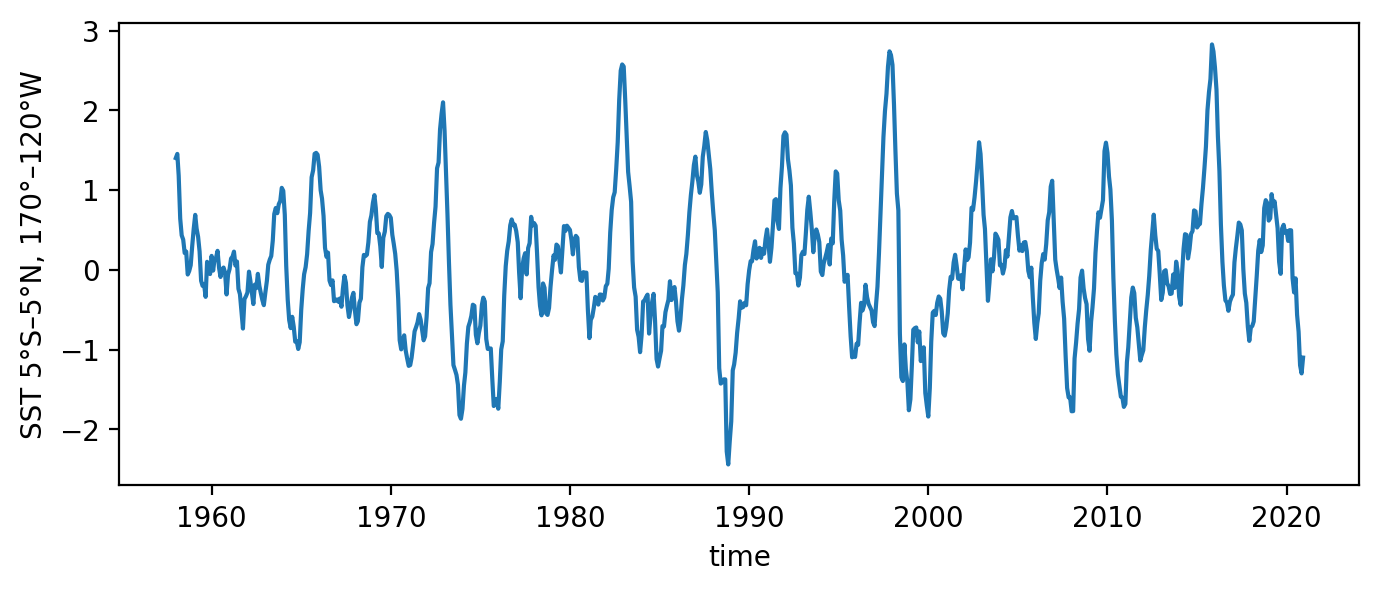

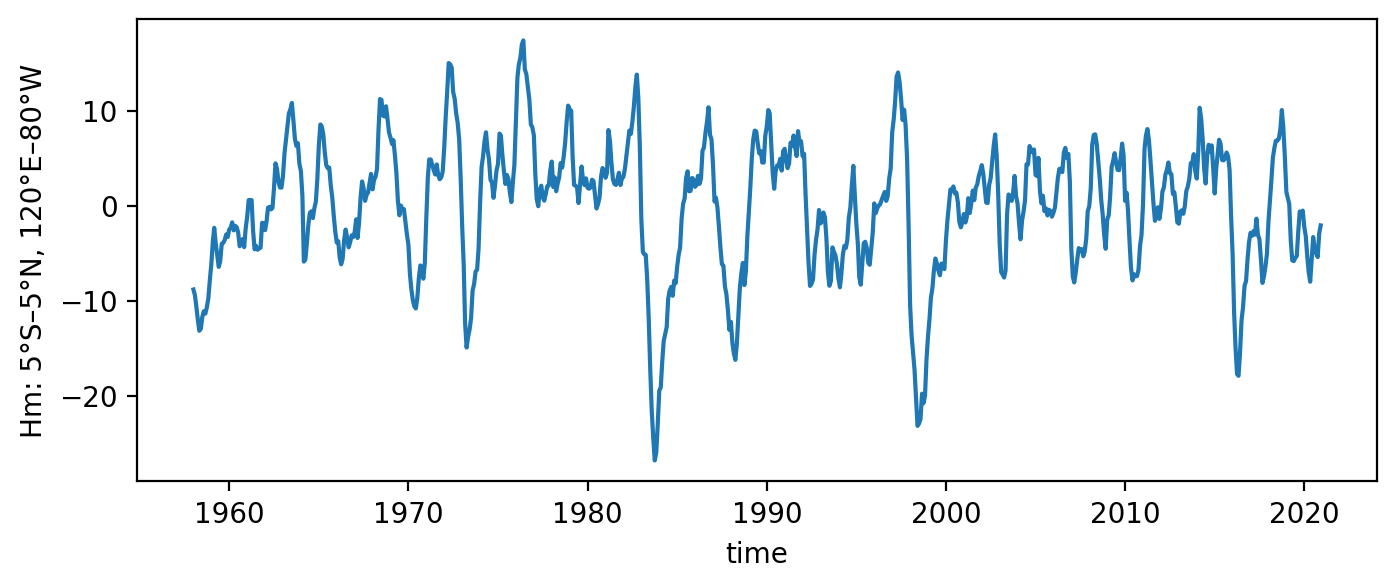

In [3]:
# load observations
# use Nino3.4 as ENSO T, equatorial Pacific mean D20 anomalies as ENSO h
xr_ds = pyCRO.ROdata_load(name='ORAS5').rename({"Nino34": "T", "Hm": "h"})

T_oras5 = xr_ds['T'][:]  # Nino 3.4 since 1979-01-01
h_oras5 = xr_ds['h'][:]     # WWV since 1979-01-01
time_oras5 = xr_ds['time'][:] # Days since 1979-01-01

T_oras5.plot(figsize=(8, 3))
h_oras5.plot(figsize=(8, 3))

### Type Linear-White-Additive

Fit linear RO with white and additive noise 

In [4]:
par_option_T = {"R": 1, "F1": 1, "b_T": 0, "c_T": 0, "d_T": 0}
par_option_h = {"F2": 1, "epsilon": 1, "b_h": 0}
par_option_noise = {"T": "white", "h": "white", "T_type": "additive"}

par_obs_LWA = pyCRO.RO_fitting(T_oras5, h_oras5, par_option_T, par_option_h, par_option_noise)
par_obs_LWA

---------------------------------------------------------------------------------
Welcome to CRO Fitting! Your fitting setups:
---------------------------------------------------------------------------------
 - Data time step is not given, defaulting to: dt = 1.0 months.
 - Time series length: N = len(T)*dt = 756.0 months.
 - Prescribed terms: {'R': 1, 'F1': 1, 'b_T': 0, 'c_T': 0, 'd_T': 0}. 
                     {'F2': 1, 'epsilon': 1, 'b_h': 0}. 
   0 - Do not prescribe. 
   1 - Prescribe only the annual mean. 
   3 - Prescribe the annual mean and annual seasonality. 
   5 - Prescribe the annual mean, annual seasonality, and semi-annual seasonality.
 - Noise options: {'T': 'white', 'h': 'white', 'T_type': 'additive'}.
 - Fitting method for T and h main equations: None.
Referring to table_default_fitting_method.txt and using LR-F
---------------------------------------------------------------------------------
All steps are successfully completed!
------------------------------------

{'R': [-0.07317026478704784],
 'F1': [0.017938268212681383],
 'F2': [1.2939079372638307],
 'epsilon': [0.008754185303737162],
 'b_T': [],
 'c_T': [],
 'd_T': [],
 'b_h': [],
 'sigma_T': [0.216845462713656],
 'sigma_h': [1.553752421021908],
 'B': [],
 'm_T': [],
 'm_h': [],
 'n_T': [1],
 'n_h': [1],
 'n_g': [2]}

### Type Seasonal-Linear-White-Additive
Fit seasonal linear RO with white and additive noise

In [5]:
par_option_T = {"R": 3, "F1": 3, "b_T": 0, "c_T": 0, "d_T": 0}
par_option_h = {"F2": 3, "epsilon": 3, "b_h": 0}
par_option_noise = {"T": "white", "h": "white", "T_type": "additive"}

par_obs_SLWA = pyCRO.RO_fitting(T_oras5, h_oras5, par_option_T, par_option_h, par_option_noise)
par_obs_SLWA

---------------------------------------------------------------------------------
Welcome to CRO Fitting! Your fitting setups:
---------------------------------------------------------------------------------
 - Data time step is not given, defaulting to: dt = 1.0 months.
 - Time series length: N = len(T)*dt = 756.0 months.
 - Prescribed terms: {'R': 3, 'F1': 3, 'b_T': 0, 'c_T': 0, 'd_T': 0}. 
                     {'F2': 3, 'epsilon': 3, 'b_h': 0}. 
   0 - Do not prescribe. 
   1 - Prescribe only the annual mean. 
   3 - Prescribe the annual mean and annual seasonality. 
   5 - Prescribe the annual mean, annual seasonality, and semi-annual seasonality.
 - Noise options: {'T': 'white', 'h': 'white', 'T_type': 'additive'}.
 - Fitting method for T and h main equations: None.
Referring to table_default_fitting_method.txt and using LR-F
---------------------------------------------------------------------------------
All steps are successfully completed!
------------------------------------

{'R': [-0.05555720362184762, 0.15643266202992212, -2.724837018919836],
 'F1': [0.012192175238321966, 0.009135876491421108, -0.8561045072488227],
 'F2': [1.1422107431233532, 0.8755377037482505, 1.031621584884776],
 'epsilon': [0.02739028639693814, 0.020607408516221015, -0.07267958345686498],
 'b_T': [],
 'c_T': [],
 'd_T': [],
 'b_h': [],
 'sigma_T': [0.19760635529456444],
 'sigma_h': [1.4672243314685984],
 'B': [],
 'm_T': [],
 'm_h': [],
 'n_T': [1],
 'n_h': [1],
 'n_g': [2]}

### Type Seasonal-Nonlinear-White-Additive
Fit seasonal nonlinear RO with white and additive noise

In [6]:
par_option_T = {"R": 3, "F1": 3, "b_T": 3, "c_T": 3, "d_T": 3}
par_option_h = {"F2": 3, "epsilon": 3, "b_h": 3}
par_option_noise = {"T": "white", "h": "white", "T_type": "additive"}

par_obs_SNWA = pyCRO.RO_fitting(T_oras5, h_oras5, par_option_T, par_option_h, par_option_noise)
par_obs_SNWA

---------------------------------------------------------------------------------
Welcome to CRO Fitting! Your fitting setups:
---------------------------------------------------------------------------------
 - Data time step is not given, defaulting to: dt = 1.0 months.
 - Time series length: N = len(T)*dt = 756.0 months.
 - Prescribed terms: {'R': 3, 'F1': 3, 'b_T': 3, 'c_T': 3, 'd_T': 3}. 
                     {'F2': 3, 'epsilon': 3, 'b_h': 3}. 
   0 - Do not prescribe. 
   1 - Prescribe only the annual mean. 
   3 - Prescribe the annual mean and annual seasonality. 
   5 - Prescribe the annual mean, annual seasonality, and semi-annual seasonality.
 - Noise options: {'T': 'white', 'h': 'white', 'T_type': 'additive'}.
 - Fitting method for T and h main equations: None.
Referring to table_default_fitting_method.txt and using LR-F
---------------------------------------------------------------------------------
All steps are successfully completed!
------------------------------------

{'R': [-0.04982239524993874, 0.15941833773505582, -2.68406670815438],
 'F1': [0.012813901875247436, 0.008483053391420874, -0.8848228299417933],
 'F2': [1.109405382383028, 0.8871565988562565, 0.9790375541196866],
 'epsilon': [0.02982668378481908, 0.01894139468167164, 0.024198432485761742],
 'b_T': [0.016378631629563104, 0.03167545049759429, -0.214994699950533],
 'c_T': [0.002840643252726443, 0.003504250810615971, -1.8778412050005295],
 'd_T': [0.007069900423760925, 0.0031200796182681238, -1.4634303845234378],
 'b_h': [0.08014094748324661, 0.06393763800594855, 2.89072085365795],
 'sigma_T': [0.19328334336766495],
 'sigma_h': [1.4614523021246],
 'B': [],
 'm_T': [],
 'm_h': [],
 'n_T': [1],
 'n_h': [1],
 'n_g': [2]}

### Type Seasonal-Nonlinear-Red-Additive
Fit seasonal nonlinear RO with red and additive noise

In [7]:
par_option_T = {"R": 3, "F1": 3, "b_T": 3, "c_T": 3, "d_T": 3}
par_option_h = {"F2": 3, "epsilon": 3, "b_h": 3}
par_option_noise = {"T": "red", "h": "red", "T_type": "additive"}

par_obs_SNRA = pyCRO.RO_fitting(T_oras5, h_oras5, par_option_T, par_option_h, par_option_noise)
par_obs_SNRA

---------------------------------------------------------------------------------
Welcome to CRO Fitting! Your fitting setups:
---------------------------------------------------------------------------------
 - Data time step is not given, defaulting to: dt = 1.0 months.
 - Time series length: N = len(T)*dt = 756.0 months.
 - Prescribed terms: {'R': 3, 'F1': 3, 'b_T': 3, 'c_T': 3, 'd_T': 3}. 
                     {'F2': 3, 'epsilon': 3, 'b_h': 3}. 
   0 - Do not prescribe. 
   1 - Prescribe only the annual mean. 
   3 - Prescribe the annual mean and annual seasonality. 
   5 - Prescribe the annual mean, annual seasonality, and semi-annual seasonality.
 - Noise options: {'T': 'red', 'h': 'red', 'T_type': 'additive'}.
 - Fitting method for T and h red noises: ARn.
   This option is defined internally within fit.py.
   Options available are: LR or AR1 or ARn.
 - Fitting method for T and h main equations: None.
Referring to table_default_fitting_method.txt and using LR-F
-----------------

{'R': [-0.04982239524993874, 0.15941833773505582, -2.68406670815438],
 'F1': [0.012813901875247436, 0.008483053391420874, -0.8848228299417933],
 'F2': [1.109405382383028, 0.8871565988562565, 0.9790375541196866],
 'epsilon': [0.02982668378481908, 0.01894139468167164, 0.024198432485761742],
 'b_T': [0.016378631629563104, 0.03167545049759429, -0.214994699950533],
 'c_T': [0.002840643252726443, 0.003504250810615971, -1.8778412050005295],
 'd_T': [0.007069900423760925, 0.0031200796182681238, -1.4634303845234378],
 'b_h': [0.08014094748324661, 0.06393763800594855, 2.89072085365795],
 'sigma_T': [0.19328334336766495],
 'sigma_h': [1.4614523021246],
 'B': [],
 'm_T': [1.571262863353877],
 'm_h': [1.6319923920979642],
 'n_T': [0],
 'n_h': [0],
 'n_g': [2]}

### Visualize the deterministic RO parameters

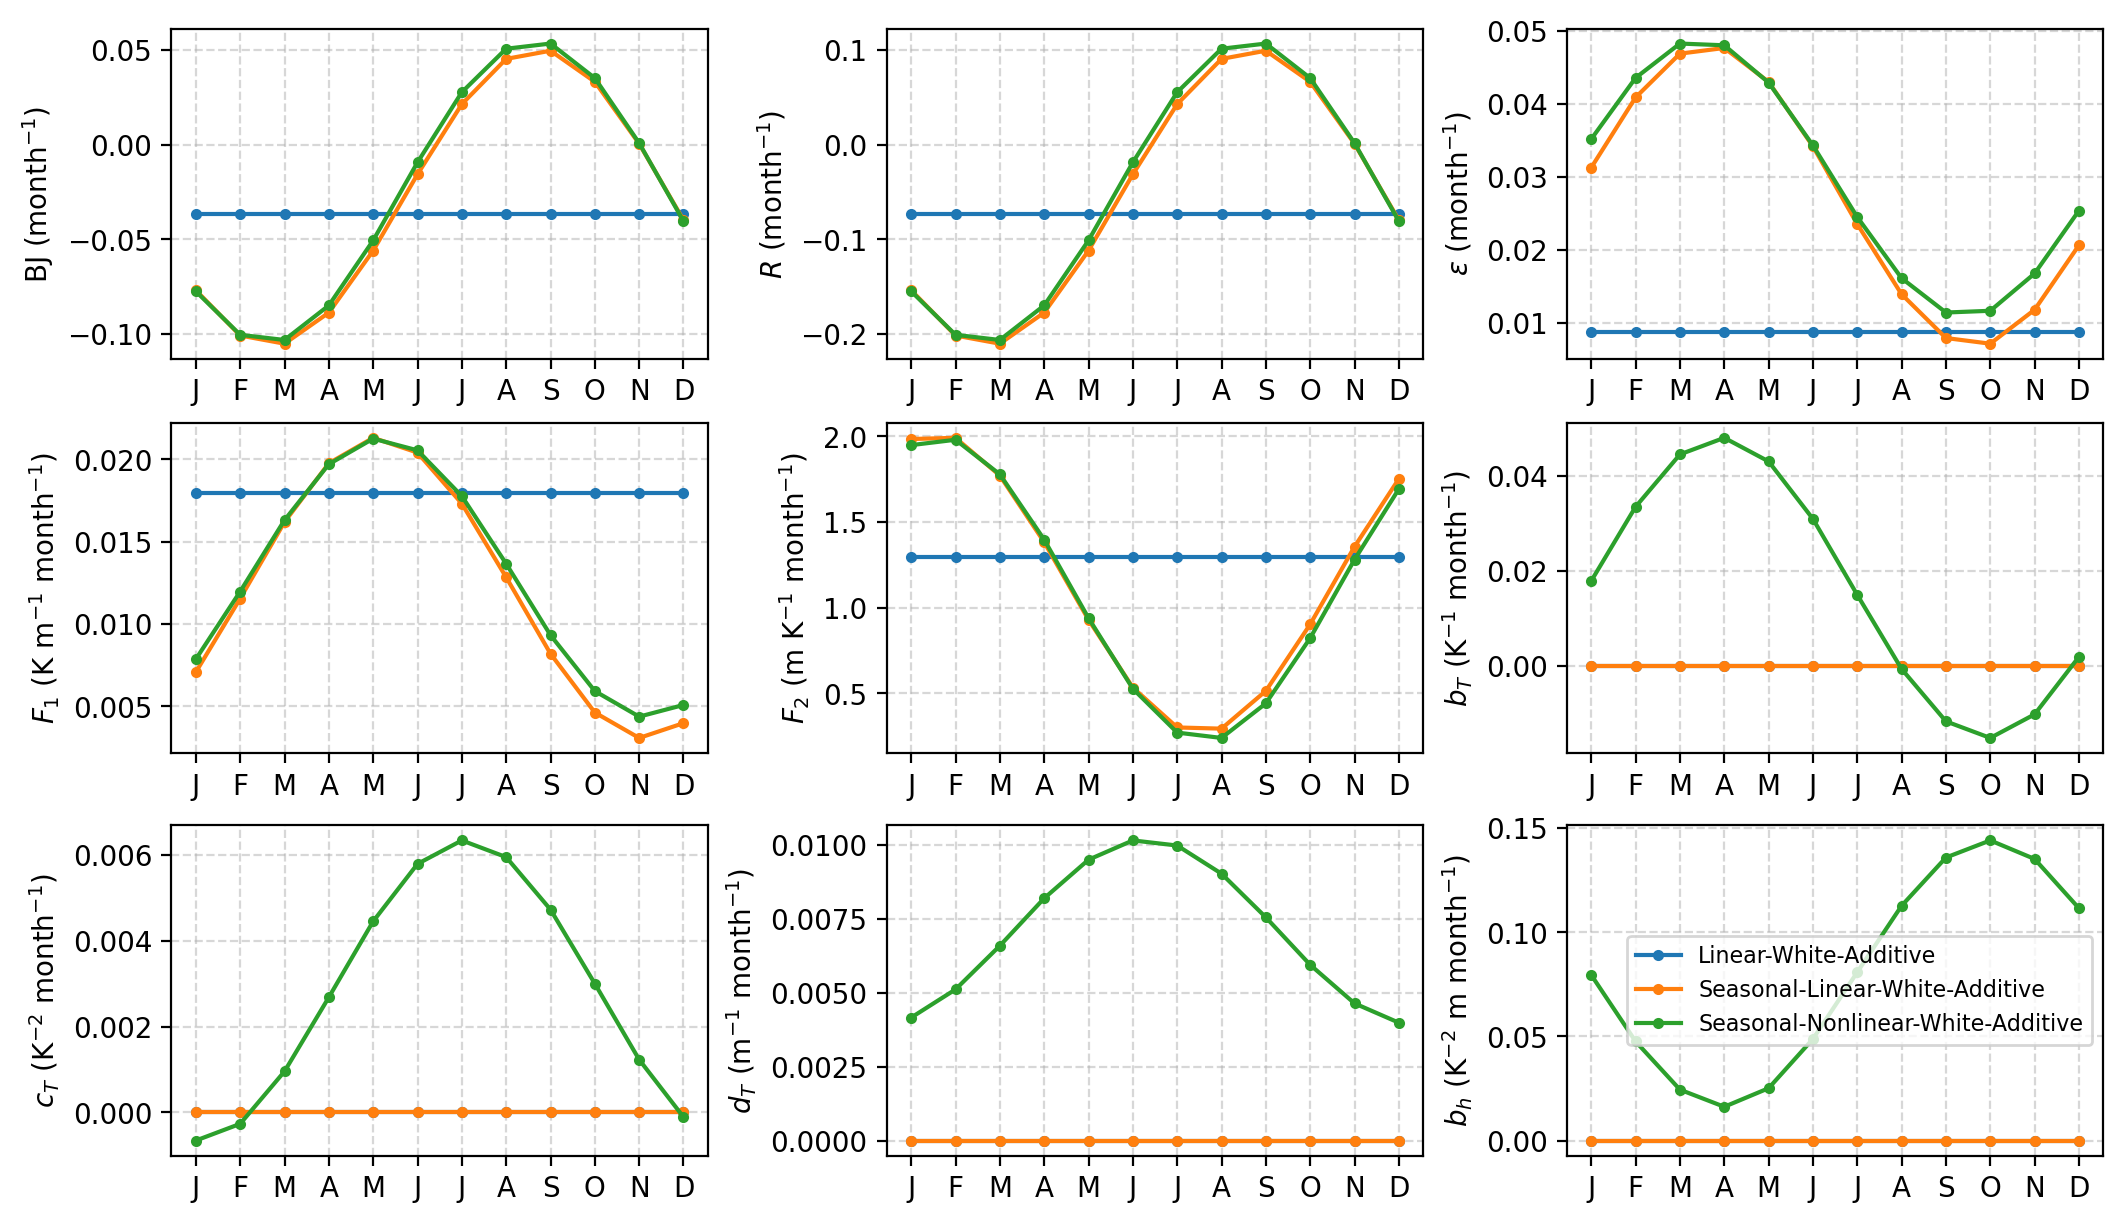

In [8]:
axes = pyCRO.plot_RO_par(par_obs_LWA, label='Linear-White-Additive', ncol=3)
axes = pyCRO.plot_RO_par(par_obs_SLWA, label='Seasonal-Linear-White-Additive', ncol=3, ax=axes)
axes = pyCRO.plot_RO_par(par_obs_SNWA, label='Seasonal-Nonlinear-White-Additive', ncol=3, ax=axes)
axes[-1].legend(fontsize=8)

## Simulating ENSO with observed RO parameters

### simulation with LWA type

In [9]:
%%time
RO_obs_LWA = pyCRO.CRO_simulate(par_obs_LWA, verbose=True)

---------------------------------------------------------------------------------
Welcome to the CRO Solver! Your simulation setup is as follows:
---------------------------------------------------------------------------------
 - Total simulation length: N = 2400 months
 - Number of ensemble members: NE = 100
 - Numerical integration time step: dt = 0.1 months (default: 0.1)
 - Data output interval: saveat = 1.0 months (default: 1.0)
 - Initial conditions: IC = [T0, h0] = [0, 0]
 - Input parameters have the expected shapes.
 - 'n_T' = 1: White noise forcing in T; 'm_T' ignored.
 - 'n_h' = 1: White noise forcing in h; 'm_h' ignored.
 - 'n_g' = 2: Additive noise is used in the T equation; 'B' is ignored.
 - Numerical integration method: NM = 'EH' (Euler–Heun method; default)
 - Data saving method: savemethod = sampling (default)
 - External forcing is not given, therefore using
   EF = {'E_T': [0.0, 0.0, 0.0, 0.0, 0.0], 'E_h': [0.0, 0.0, 0.0, 0.0, 0.0]}.
 - noise_custom = None: System-g

In [10]:
%%time

RO_obs_SLWA = pyCRO.CRO_simulate(par_obs_SLWA, verbose=False)
RO_obs_SNWA = pyCRO.CRO_simulate(par_obs_SNWA, verbose=False)
RO_obs_SNRA = pyCRO.CRO_simulate(par_obs_SNRA, verbose=False)


CPU times: user 11.4 s, sys: 151 ms, total: 11.6 s
Wall time: 11.6 s


calculation of seasonal standard deivation

In [11]:
%%time

seaSD_obs = xr_ds.groupby('time.month').std('time')
seaSD_obsRO_LWA = RO_obs_LWA.groupby('time.month').std('time')
seaSD_obsRO_SLWA = RO_obs_SLWA.groupby('time.month').std('time')
seaSD_obsRO_SNWA = RO_obs_SNWA.groupby('time.month').std('time')
seaSD_obsRO_SNRA = RO_obs_SNRA.groupby('time.month').std('time')


CPU times: user 93 ms, sys: 3.99 ms, total: 97 ms
Wall time: 94.9 ms


### Effect of seasonal cycle of RO linear parameters

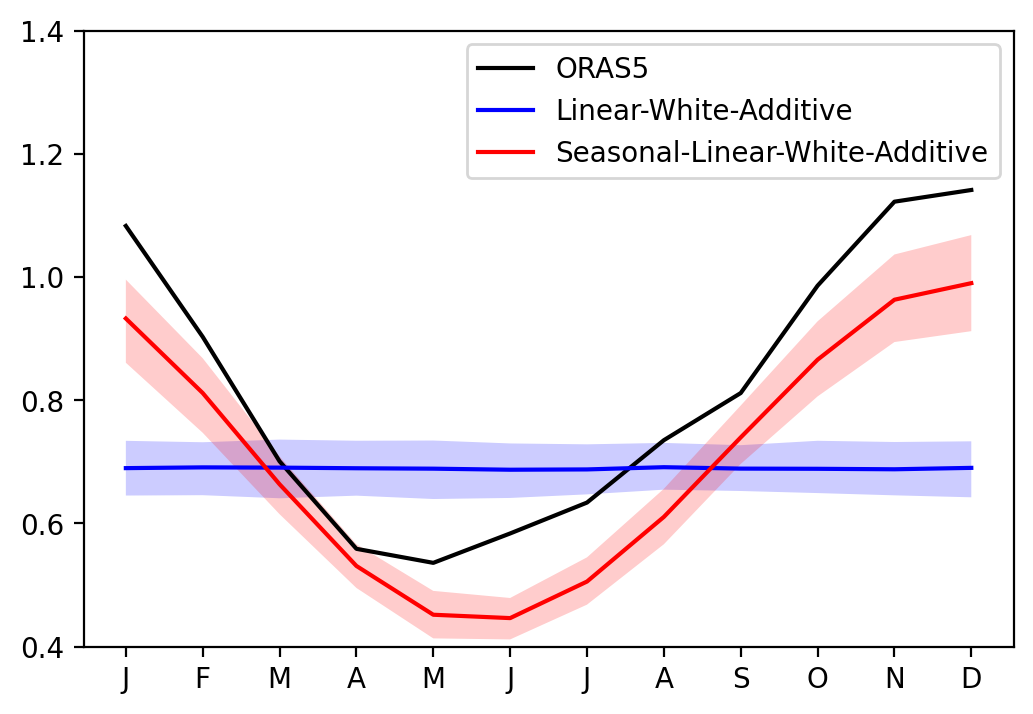

In [12]:
sel_var = 'T'

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(seaSD_obs.month, seaSD_obs[sel_var], c='k', label='ORAS5')

ax.plot(seaSD_obsRO_LWA.month, seaSD_obsRO_LWA[sel_var].mean('member'), c='blue', label='Linear-White-Additive')
ax.fill_between(seaSD_obsRO_LWA.month, seaSD_obsRO_LWA[sel_var].quantile(0.1, dim='member'), seaSD_obsRO_LWA[sel_var].quantile(0.9, dim='member'), fc='blue', alpha=0.2)

ax.plot(seaSD_obsRO_SLWA.month, seaSD_obsRO_SLWA[sel_var].mean('member'), c='red', label='Seasonal-Linear-White-Additive')
ax.fill_between(seaSD_obsRO_SLWA.month, seaSD_obsRO_SLWA[sel_var].quantile(0.1, dim='member'), seaSD_obsRO_SLWA[sel_var].quantile(0.9, dim='member'), fc='red', alpha=0.2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_ylim([0.4, 1.4])
ax.legend()


### Effect of RO nonlinear parameters

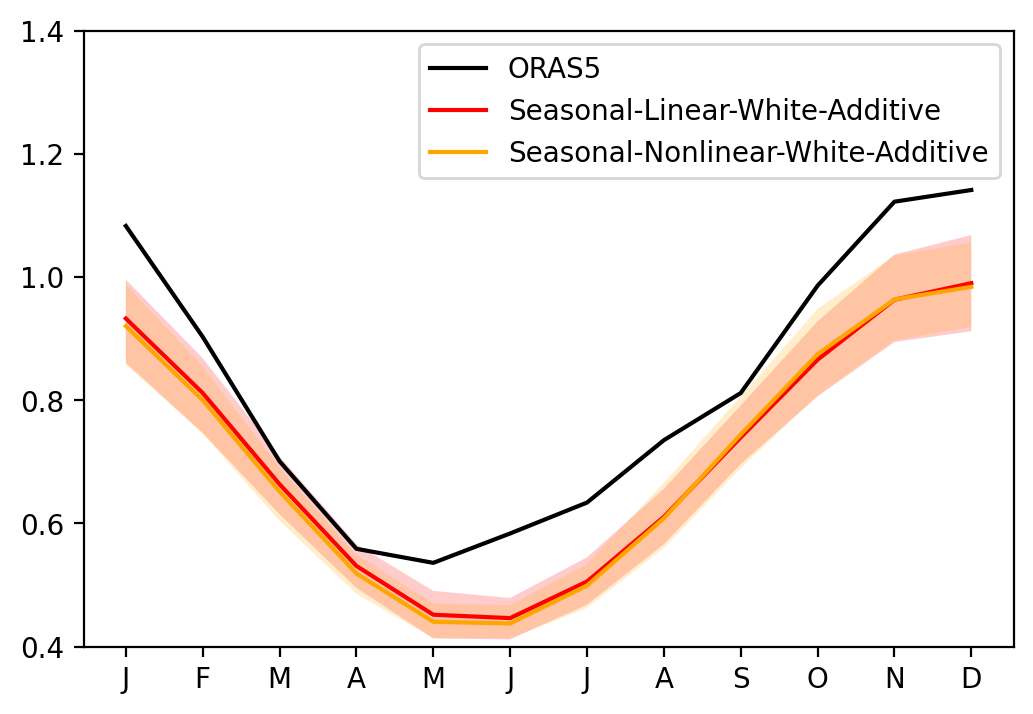

In [13]:
sel_var = 'T'

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(seaSD_obs.month, seaSD_obs[sel_var], c='k', label='ORAS5')

ax.plot(seaSD_obsRO_SLWA.month, seaSD_obsRO_SLWA[sel_var].mean('member'), c='red', label='Seasonal-Linear-White-Additive')
ax.fill_between(seaSD_obsRO_SLWA.month, seaSD_obsRO_SLWA[sel_var].quantile(0.1, dim='member'), seaSD_obsRO_SLWA[sel_var].quantile(0.9, dim='member'), fc='red', alpha=0.2)

ax.plot(seaSD_obsRO_SNWA.month, seaSD_obsRO_SNWA[sel_var].mean('member'), c='orange', label='Seasonal-Nonlinear-White-Additive')
ax.fill_between(seaSD_obsRO_SNWA.month, seaSD_obsRO_SNWA[sel_var].quantile(0.1, dim='member'), seaSD_obsRO_SNWA[sel_var].quantile(0.9, dim='member'), fc='orange', alpha=0.2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_ylim([0.4, 1.4])
ax.legend()

### Red noise vs White noise

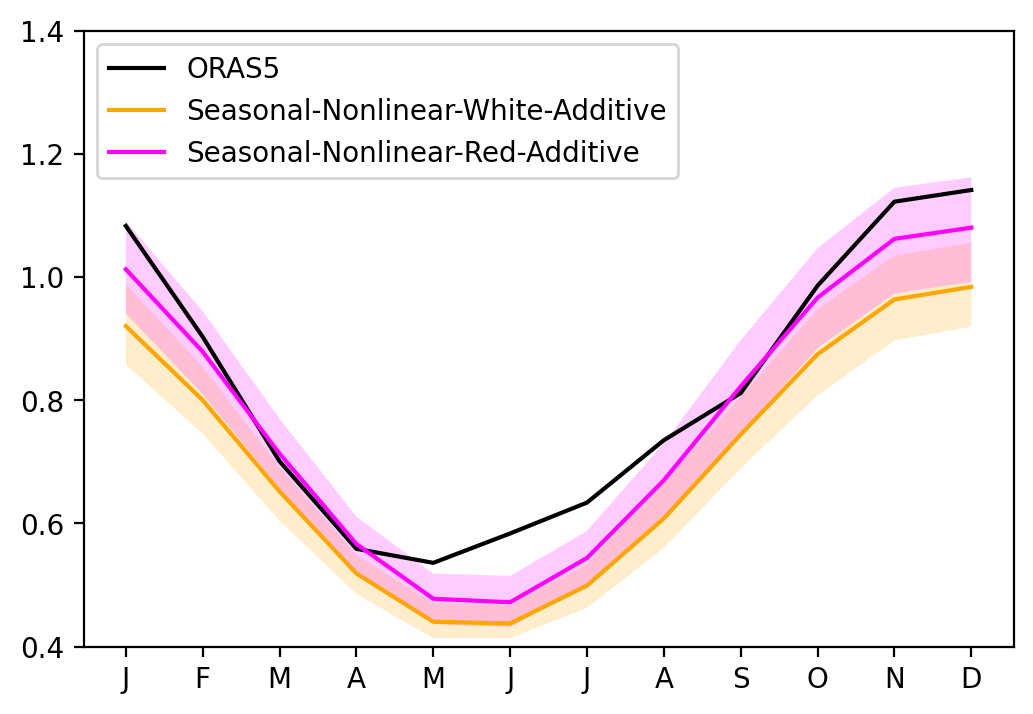

In [14]:
sel_var = 'T'

fig, ax = plt.subplots(1, 1, figsize=(6, 4))

ax.plot(seaSD_obs.month, seaSD_obs[sel_var], c='k', label='ORAS5')

ax.plot(seaSD_obsRO_SNWA.month, seaSD_obsRO_SNWA[sel_var].mean('member'), c='orange', label='Seasonal-Nonlinear-White-Additive')
ax.fill_between(seaSD_obsRO_SNWA.month, seaSD_obsRO_SNWA[sel_var].quantile(0.1, dim='member'), seaSD_obsRO_SNWA[sel_var].quantile(0.9, dim='member'), fc='orange', alpha=0.2)

ax.plot(seaSD_obsRO_SNRA.month, seaSD_obsRO_SNRA[sel_var].mean('member'), c='magenta', label='Seasonal-Nonlinear-Red-Additive')
ax.fill_between(seaSD_obsRO_SNRA.month, seaSD_obsRO_SNRA[sel_var].quantile(0.1, dim='member'), seaSD_obsRO_SNRA[sel_var].quantile(0.9, dim='member'), fc='magenta', alpha=0.2)

ax.set_xticks(range(1, 13))
ax.set_xticklabels(["J","F","M","A","M","J","J","A","S","O","N","D"])
ax.set_ylim([0.4, 1.4])
ax.legend()

## Advanced Usage (optional)

**`par_fitted = pyCRO.RO_fitting(T, h, par_option_T, par_option_h, par_option_noise, method_fitting)`**  

**`par_fitted = pyCRO.RO_fitting(T, h, par_option_T, par_option_h, par_option_noise, method_fitting, dt)`**

- The following block sets additional **optional settings** for the RO parameter fitting.
- The user may skip specifying these options. If the user doesn't specify these options, the RO parameter fitting runs with the default settings.
  
- method_fitting specifies the parameter fitting method:
    - `"LR-F"`: Linear regression (tendency with forward differencing scheme) 
    - `"LR-C"`: Linear regression (tendency with central differencing scheme)
    - `"LR-F-MAC"`: Linear regression (tendency with forward differencing scheme) with Moments Analytical Constraints estimation for T noise parameters 
    - `"MLE"`: Maximum Likelihood Estimation (tendency with forward differencing scheme)

- dt specifies time interval of input T and h time series in month (default = 1.0).
  
- The default method depends on the specified RO type, as indicated in `"table_default_fitting_method.txt"`.
- Details of the fitting methods are documented in the manual and the accompanying paper.
  